2026-03-24 06:23:09.025270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774333389.180536    2874 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774333389.224630    2874 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774333389.562974    2874 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774333389.563013    2874 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774333389.563015    2874 computation_placer.cc:177] computation placer alr

[40846 18917 30220 ... 15759  3047 39445]
(48000, 28, 28)


W0000 00:00:1774333396.384684    2874 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<tf.Variable 'Variable:0' shape=(10,) dtype=float32, numpy=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)>
Tensor("add:0", shape=(48, 10), dtype=float32)
Epoch 1, Loss: 2.590968
Epoch 2, Loss: 1.117072
Epoch 3, Loss: 0.920986
Epoch 4, Loss: 0.813770
Epoch 5, Loss: 0.742875
Epoch 6, Loss: 0.691000
Epoch 7, Loss: 0.650438
Epoch 8, Loss: 0.617422
Epoch 9, Loss: 0.589816
Epoch 10, Loss: 0.566233
Epoch 11, Loss: 0.545809
Epoch 12, Loss: 0.527976
Epoch 13, Loss: 0.512296
Epoch 14, Loss: 0.498396
Epoch 15, Loss: 0.485968
Epoch 16, Loss: 0.474767
Epoch 17, Loss: 0.464599
Epoch 18, Loss: 0.455315
Epoch 19, Loss: 0.446794
Epoch 20, Loss: 0.438941
Epoch 21, Loss: 0.431679
Epoch 22, Loss: 0.424943
Epoch 23, Loss: 0.418679
Epoch 24, Loss: 0.412843
Epoch 25, Loss: 0.407394
Epoch 26, Loss: 0.402300
Epoch 27, Loss: 0.397530
Epoch 28, Loss: 0.393056
Epoch 29, Loss: 0.388856
Epoch 30, Loss: 0.384906
Epoch 31, Loss: 0.381186
Epoch 32, Loss: 0.377679
Epoch 33, Loss: 0.374367
Epoch 34, Loss

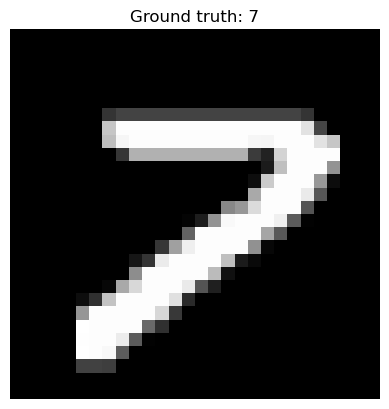

Model prediction: 7


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt


# Load data
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data() # it will two outputs -> 60k images and 60k  labels, 10k images and 10k labels 
#x_train_full = its an array [image0, image1, image2, image3, image4, image5.... image59,999 60 thousand images
#x_test = its an array [image0, image1, image2, image3, image4, image5.... image9999] 10 thousand images

# Shuffle data
indices = np.arange(x_train_full.shape[0]) #shape is (60000, 28, 28) #60000 0 1 2 3 4 5 6 7 8 9 10 11 ...... 59999
np.random.shuffle(indices) # 11000 7 8 2423 3 1900 23 21 49 45 32 23000 ... but the total quantity will be 60k 0-59.999k
print(indices)

#use them as index what is index ['harry' index=0, 'potter' i=1, 'hoghwarts' i=2, 'magic' i=3, 'occult science' i=4]
x_train_full = x_train_full[indices]  #now if first image is 29,999th position
y_train_full = y_train_full[indices] #first label should be also of image at 29.99k position
#for eg first image was of digit (5) which was taken from position 213th from original dataset 
#if we dont shuffle the labels in same manner we will get label as per original dataset that will not match with shuffled dataset

# Split into train and validation sets     spliting training dataset in two parts train and validation
#suppose i trained my model with training dataset
#in next step we tested the model with test DATASET and we got the accuracy =0.789 loss is 0.211
# now i made the necessary changes trained again with training dataset but Now when i test my model again the model already knows about test images 
#becuae earlier we used them for testing , now to solve this issue we create three datasets train one for validation and one for final testing we keep one dataset  
validation_size = int(0.2 * x_train_full.shape[0]) # shape [0] = 60000 so 0.4 of the 60000 =  12000 
x_val = x_train_full[:validation_size] # will get images from the training dataset from index 0 till 12k
y_val = y_train_full[:validation_size] # will get lalbels from the training labels from index 0 till 12k
x_train = x_train_full[validation_size:]  # will get images from the training dataset from index 12k to 60k which is 48k
y_train = y_train_full[validation_size:]
# what is [ start: stop : step] but we are only using [start:stop] suppose Abcd is an array containing 20k values
#i want to access first 5k values what i can do is Abcd[start:stop] what is stop = 5k start=0 so [0:5k] or
#if you dont give start it will automatically start from 0 and if you dont give any stop position it will go till 20k position 


# Normalization and flattening  (48000, 28, 28) this (28,28) means it is a square image but (28x28) this is 1d array
# so (28,28) means there are 28 rows and each row has 28 values so we stack all rows in one row it will be 784 values
print(x_train.shape)
#128 /255 = 0.5   255/255 =1 0/255 =0 
x_train_flat = (x_train.reshape(-1, 28*28).astype(np.float32) -128) /128 #rather than unsigned int which is 0-255   -1 to 1 or you can have 0 -1
x_test_flat = (x_test.reshape(-1, 28*28).astype(np.float32))-128 / 128 #becuase maximum valu can be 255/255 =1   0/255=0  anything in between will be points in between 0-1 
#now your no. of values for 1 input is 784 soo the mutiplication in each neuron will be w0*x0, w1*x1 + w2*x2 + w3*x3 + w4*x4 + ..w783*x783 + B
# when this multiplication will happen answer will be very big it will be huge number so we want to standardize it 
#what will be the maximum value for pixel? it is 255 i want all values converted in between 0 -1 or {-1 to 1} we are doing -1 to 1
# if i want to convert p1=255 as 1, p1=128 as 0, p1=0 as -1 and  p2=127  take half of 256/2= 128, (0-128)/128= -0.007 
#our image is of size 28 x 28 in which each pixel contains value in between  0-255 value 
#now that if we want to pass to deep learning model we need to send it as 1d array rather than 28x28 so we will transform
#all the values of image in one single line or array [p0, p1, p2, p3, p4, p5, p6, p7, p8 p9,.......p783] so 28 x 28 = 784 but if we include 0 its 783 


# Model parameters
Input_Features = 28 * 28  #784  number of weights
Output_Classes = 10 #0-9 that is total 10 classes = total number of neurons 
Weights = tf.Variable(tf.random.truncated_normal(shape=(Input_Features, Output_Classes), stddev=1))
biases = tf.Variable(tf.zeros(shape=(Output_Classes,)))
print(biases)
batch_size = 48 # it need images in ram in working memory so wwe cannot pass 48,000 images in working memory but we will pass  48 images
num_epochs = 55  # how man times you are going to pass all the inputs or complete training dataset, so 55 times we will pass 48k images 
num_samples = x_train_flat.shape[0]
num_batches = int(np.ceil(num_samples / batch_size)) # 48,000/48 = 1000

def linear(x):
    return   tf.matmul(x, Weights) + biases

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = linear(x_batch)
        loss = loss_fn(y_batch, logits)
    print(logits)
    gradients = tape.gradient(loss, [Weights, biases])
    optimizer.apply_gradients(zip(gradients, [Weights, biases]))
    return loss

# Training loop
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for b in range(num_batches): # we want to pass our dataset of 48k images in small chunks of size 48 so we need to pass 1000 times
        #this first for loop is creating numbers from (0 to 999) (0, 1, 2, 3, 4, 5, 6, 7, 8, .... 999)
        start = b * batch_size  # one dataset [ 0 to 48k] but we want first 48 in first loop so  [0 -48, 48 - 96, 96-144]
        end = min(start + batch_size, num_samples) #( 48, 48000)
        x_batch = x_train_flat[start:end]
        y_batch = y_train[start:end]
        batch_loss = train_step(x_batch, y_batch)
        epoch_loss += batch_loss.numpy() * (end - start)
    avg_epoch_loss = epoch_loss / num_samples
    print(f"Epoch {epoch+1}, Loss: {avg_epoch_loss:.6f}")

# -------- Show test case output --------
import random

# Pick a random test case
idx = random.randint(0, x_test.shape[0] - 1)
sample_image = x_test[idx]   # shape (28, 28)
sample_label = y_test[idx]

# Show the test image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Ground truth: {sample_label}")
plt.axis('off')
plt.show()

# Prepare the image for the model
sample_image_flat = (sample_image.reshape(1, 28*28).astype(np.float32) - 128) / 128.0

# Model prediction
logits = linear(sample_image_flat)
predicted_class = np.argmax(logits.numpy())

print(f"Model prediction: {predicted_class}")


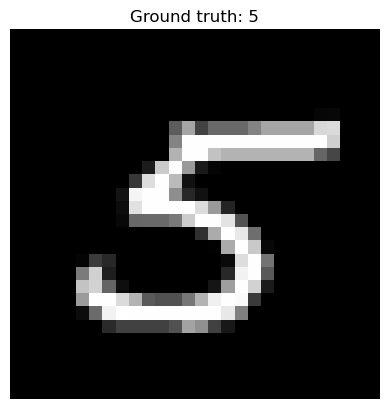

Model prediction: 5


In [8]:
import random

# Pick a random test case
idx = random.randint(0, x_test.shape[0] - 1)
sample_image = x_test[idx]   # shape (28, 28)
sample_label = y_test[idx]

# Show the test image
plt.imshow(sample_image, cmap='gray')
plt.title(f"Ground truth: {sample_label}")
plt.axis('off')
plt.show()

# Prepare the image for the model
sample_image_flat = (sample_image.reshape(1, 28*28).astype(np.float32) - 128) / 128.0

# Model prediction
logits = linear(sample_image_flat)
predicted_class = np.argmax(logits.numpy())

print(f"Model prediction: {predicted_class}")